Bài tập 1:

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import wittgenstein as lw

# 1. Tải tập dữ liệu Iris 
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

X = df.drop('target', axis=1)
y = df['target']

# 2. Chia tập dữ liệu 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Huấn luyện thuật toán RIPPER  
models = {}
classes = ['setosa', 'versicolor', 'virginica']

print("CÁC LUẬT PHÂN LOẠI")
for cls in classes:
    y_train_binary = (y_train == cls)
    
    clf = lw.RIPPER(random_state=42)
    clf.fit(X_train, y_train_binary)
    models[cls] = clf
    
    # In ra luật
    print(f"\nLuật để nhận diện [{cls}]:")
    clf.out_model()
    
print("-" * 50)

# 4. Dự đoán & Đánh giá 
# DataFrame chứa xác suất dự đoán của từng class
probs = pd.DataFrame(index=X_test.index)

# Lấy xác suất dự đoán (predict_proba) từ từng mô hình
for cls, clf in models.items():
    probs[cls] = clf.predict_proba(X_test)[:, 1]

# Lựa chọn class có xác suất cao nhất cho mỗi dòng
y_pred = probs.idxmax(axis=1)

print("\nĐÁNH GIÁ MÔ HÌNH")
print(f"Độ chính xác: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

CÁC LUẬT PHÂN LOẠI

Luật để nhận diện [setosa]:
[[petalwidth(cm)=<0.2] V
[petalwidth(cm)=0.2-0.4] V
[petallength(cm)=1.5-1.67]]

Luật để nhận diện [versicolor]:
[[petallength(cm)=4.25-4.6] V
[petallength(cm)=3.96-4.25] V
[petallength(cm)=1.67-3.96 ^ petalwidth(cm)=0.4-1.2] V
[petallength(cm)=4.6-5.0 ^ petalwidth(cm)=1.3-1.5]]

Luật để nhận diện [virginica]:
[[petallength(cm)=>5.81] V
[petallength(cm)=5.32-5.81] V
[petallength(cm)=5.0-5.32] V
[petallength(cm)=4.6-5.0 ^ sepalwidth(cm)=<2.5] V
[petalwidth(cm)=1.5-1.8 ^ sepallength(cm)=6.0-6.3]]
--------------------------------------------------

ĐÁNH GIÁ MÔ HÌNH
Độ chính xác: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro a

1. Luật nào dễ diễn giải nhất?
    - Luật để nhận diện lớp Setosa là dễ diễn giải nhất. 
    - Nhìn vào kết quả, luật của Setosa bao gồm các điều kiện rất đơn giản và ngắn gọn, chủ yếu xoay quanh việc đài hoa/cánh hoa có kích thước nhỏ hơn hẳn (ví dụ: petalwidth <= 0.2 hoặc 0.2 - 0.4). Và dữ liệu của nó tách biệt hoàn toàn, điều này giúp luật của Setosa dễ diễn giải .

2. Lớp Iris nào được phân loại tốt nhất? 
    - Lớp Setosa luôn là lớp được phân loại tốt nhất.
    - Lý do là vì xét trên không gian đặc trưng, dữ liệu của hoa Setosa tách biệt hoàn toàn thành một cụm riêng so với hai loại Versicolor và Virginica (hai loại này thường có ranh giới chồng lấn lên nhau một chút).

3. Ưu điểm chính của RIPPER so với các mô hình hộp đen? 
    - Ưu điểm vượt trội nhất là khả năng diễn giải tuyệt đối. Các mô hình hộp đen như Mạng nơ-ron có thể cho kết quả đúng nhưng không thể giải thích tại sao chúng lại dự đoán như vậy. Ngược lại, RIPPER trích xuất ra các luật logic dạng văn bản (Nếu A và B thì C). Nhờ đó, người dùng có thể dễ dàng kiểm chứng tính hợp lý của mô hình, đồng thời dễ dàng chuyển đổi các luật này thành các câu lệnh IF-THEN trong lập trình (như C++, Python) hoặc câu truy vấn SQL để tích hợp vào hệ thống thực tế.

In [3]:

test_sizes = [0.30, 0.25, 0.20]
classes = ['setosa', 'versicolor', 'virginica']

print("SO SÁNH SỐ LƯỢNG LUẬT VỚI CÁC TỶ LỆ CHIA KHÁC NHAU")

for size in test_sizes:
    # 1. Chia lại dữ liệu
    X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
        X, y, test_size=size, random_state=42, stratify=y
    )
    
    total_rules = 0
    
    # 2. Huấn luyện 
    for cls in classes:
        y_train_binary = (y_train_ext == cls)
      
        clf_ext = lw.RIPPER(random_state=42)
        clf_ext.fit(X_train_ext, y_train_binary)
        
        total_rules += len(clf_ext.ruleset_)
        
    train_ratio = int((1 - size) * 100)
    test_ratio = int(size * 100)
    
    print(f"Tỷ lệ Train:Test = {train_ratio}:{test_ratio} | Tổng số luật sinh ra (cho cả 3 loại): {total_rules}")

SO SÁNH SỐ LƯỢNG LUẬT VỚI CÁC TỶ LỆ CHIA KHÁC NHAU
Tỷ lệ Train:Test = 70:30 | Tổng số luật sinh ra (cho cả 3 loại): 14
Tỷ lệ Train:Test = 75:25 | Tổng số luật sinh ra (cho cả 3 loại): 10
Tỷ lệ Train:Test = 80:20 | Tổng số luật sinh ra (cho cả 3 loại): 12


Kết luận mô hình phân loại RIPPER:

1. Hiệu suất dự đoán: Mô hình hoạt động khá hiệu quả với tập dữ liệu nhỏ và cấu trúc đơn giản như Iris, đạt độ chính xác ~93.3%. Dù vậy, hiệu suất của nó có thể hơi kém nếu đem so sánh với các thuật toán học máy phức tạp hơn (như Random Forest hay SVM) trên các tập dữ liệu có độ nhiễu cao.

2. Khả năng diễn giải : Khả năng xuất ra các quy tắc phân loại rõ ràng giúp các nhà phân tích dữ liệu và ngay cả người không có chuyên môn kỹ thuật cũng có thể hiểu được cơ sở ra quyết định của mô hình.

3. Điểm mạnh:
    - Rất minh bạch, logic rõ ràng.
    - Khả năng loại bỏ các đặc trưng không quan trọng khi xây dựng luật.
    - Dễ dàng xuất và nhúng các luật trực tiếp vào các phần mềm quản lý/vận hành doanh nghiệp.

4. Hạn chế:
    - Thuật toán mặc định gặp khó khăn với phân loại đa lớp và thường yêu cầu phải chia nhỏ bài toán bằng phương pháp One-vs-Rest.
    - Với dữ liệu số liên tục như tập Iris, thuật toán phải tự động chia khoảng, đôi khi dẫn đến việc ranh giới phân loại bị cứng nhắc.
    - Có thể sinh ra quá nhiều điều kiện nhỏ lẻ nếu dữ liệu quá phức tạp và không được phân chia hợp lý.

Bài tập 2:

ĐỘ CHÍNH XÁC VỚI CÁC GIÁ TRỊ k
Độ chính xác với k = 1: 0.9667
Độ chính xác với k = 3: 0.9333
Độ chính xác với k = 5: 0.9333
Độ chính xác với k = 7: 0.9667
Độ chính xác với k = 9: 0.9667


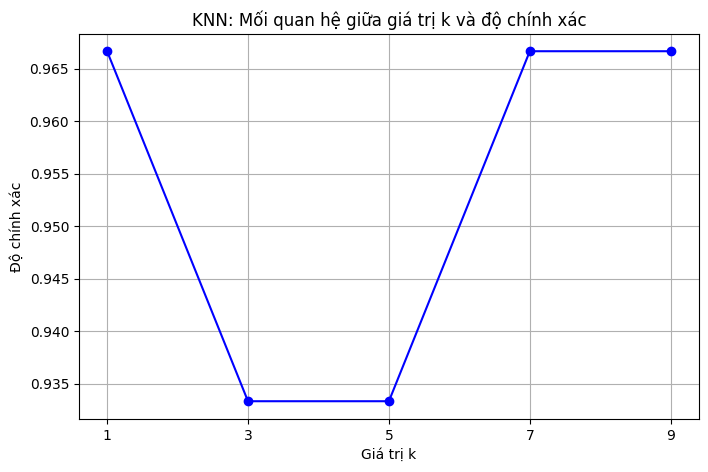


 ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT (k = 1) 
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load data
iris = load_iris()
X = iris.data 
y = iris.target

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train KNN với các k khác nhau và lưu độ chính xác 
k_values = [1, 3, 5, 7, 9] 
accuracies = []

print("ĐỘ CHÍNH XÁC VỚI CÁC GIÁ TRỊ k")
for k in k_values:
    # Huấn luyện mô hình 
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Dự đoán và tính độ chính xác
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Độ chính xác với k = {k}: {acc:.4f}")

# 5. Vẽ biểu đồ k vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('KNN: Mối quan hệ giữa giá trị k và độ chính xác')
plt.xlabel('Giá trị k')
plt.ylabel('Độ chính xác')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# 7. Đánh giá mô hình tốt nhất 
best_index = np.argmax(accuracies)
best_k = k_values[best_index]

print(f"\n ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT (k = {best_k}) ")
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)

# Báo cáo Confusion Matrix và Classification Report 
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

1. Tại sao KNN thường yêu cầu chuẩn hóa đặc trưng? 

    - KNN hoạt động dựa trên việc tính toán khoảng cách (thường là khoảng cách Euclidean) giữa các điểm dữ liệu. Nếu các đặc trưng đầu vào có thang đo khác biệt lớn (ví dụ: một cái đo bằng milimet, một cái đo bằng mét), đặc trưng có giá trị lớn sẽ áp đảo và chi phối hoàn toàn việc tính toán khoảng cách. Việc dùng StandardScaler giúp đưa tất cả các đặc trưng về cùng một mức độ ảnh hưởng (thường là trung bình = 0, phương sai = 1), giúp mô hình công bằng hơn.


2. Điều gì xảy ra khi k quá nhỏ hoặc quá lớn? 
    - Khi k quá nhỏ (ví dụ k = 1): Mô hình sẽ rất nhạy cảm với dữ liệu nhiễu (outliers) trong tập huấn luyện, dẫn đến hiện tượng Overfitting. Ranh giới quyết định sẽ rất gấp khúc.
    - Khi k quá lớn (tiến gần đến số lượng mẫu): Mô hình sẽ bị làm phẳng, dẫn đến hiện tượng Underfitting. Nó sẽ có xu hướng dự đoán toàn bộ dữ liệu mới thuộc về lớp có số lượng mẫu đông nhất.

3. Tại sao KNN được gọi là lazy learner (người học lười biếng)? 

    - Vì trong pha huấn luyện, KNN thực chất... chẳng học ra một phương trình hay quy luật phân loại nào cả (không tốn thời gian tính toán). Nó chỉ đơn thuần là ghi nhớ lại toàn bộ dữ liệu huấn luyện. Quá trình tính toán thực sự tốn kém (đo khoảng cách từ điểm mới đến tất cả các điểm cũ) chỉ diễn ra khi nó được yêu cầu dự đoán.

Kết luận mô hình KNN:
1. Hiệu suất dự đoán: Rất cao trên tập dữ liệu Iris (thường đạt độ chính xác từ 95% - 100% tùy vào cách chia dữ liệu và giá trị k).

2. Khả năng diễn giải: Thấp. Đây là một mô hình hộp đen (black-box model). Dù có thể trực quan hóa bằng biểu đồ phân tán (scatter plot) trên dữ liệu 2D, ta không thể trích xuất ra các luật logic rõ ràng như thuật toán RIPPER.

3. Điểm mạnh: Dễ hiểu ý tưởng, dễ cài đặt. Hoàn toàn không đưa ra giả định gì về phân phối của dữ liệu (non-parametric), rất hiệu quả với dữ liệu có ranh giới quyết định phi tuyến tính.

4. Hạn chế: Chi phí tính toán cực kỳ lớn khi dự đoán với tập dữ liệu "khủng", yêu cầu dung lượng bộ nhớ lớn (vì phải lưu toàn bộ dữ liệu huấn luyện), nhạy cảm với dữ liệu nhiễu và rất cần bước chuẩn hóa dữ liệu đầu vào

Bài tập 3:

In [6]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Tải dữ liệu
iris = load_iris()
X = iris.data
y = iris.target

# 2. Chia tập huấn luyện / kiểm thử 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Huấn luyện mô hình Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 4. Dự đoán và đánh giá mô hình 
y_pred = gnb.predict(X_test)

print("ĐÁNH GIÁ MÔ HÌNH NAIVE BAYES")
print(f"Độ chính xác: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 5. In xác suất dự đoán 
print("\nXÁC SUẤT DỰ ĐOÁN CHO 5 MẪU ĐẦU TIÊN")
# Hàm predict_proba trả về xác suất phần trăm dữ liệu thuộc về từng lớp
probs = gnb.predict_proba(X_test[:5])

# Đưa vào DataFrame cho dễ nhìn
df_probs = pd.DataFrame(probs, columns=iris.target_names)
df_probs.index = [f"Sample {i+1}" for i in range(5)]
print(df_probs.to_string(float_format="%.4f"))

ĐÁNH GIÁ MÔ HÌNH NAIVE BAYES
Độ chính xác: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


XÁC SUẤT DỰ ĐOÁN CHO 5 MẪU ĐẦU TIÊN
          setosa  versicolor  virginica
Sample 1  1.0000      0.0000     0.0000
Sample 2  0.0000      0.0877     0.9123
Sample 3  0.0000      1.0000     0.0000
Sample 4  0.0000      1.0000     0.0000
Sample 5  1.0000      0.0000     0.0000


1. Mẫu nào được dự đoán với độ tự tin cao nhất?
    - Là các Sample 1, Sample 3, Sample 4 và Sample 5. 
    - Ở các mẫu này, mô hình đưa ra xác suất tuyệt đối là 1.0000 (100%) cho một lớp duy nhất (Setosa hoặc Versicolor). Điều này có nghĩa là các đặc trưng của những bông hoa này rất rõ ràng và mô hình hoàn toàn chắc chắn 100% về quyết định phân loại của mình.

2. Mẫu nào tỏ ra thiếu chắc chắn nhất?
    - Là Sample 2. 
    - Mặc dù mô hình vẫn nghiêng hẳn về dự đoán là hoa Virginica với xác suất khá cao (0.9123 hay 91.23%), nhưng nó vẫn còn một phần xác suất cho hoa Versicolor (0.0877 hay 8.77%). Trong số 5 mẫu thử nghiệm, đây là mẫu duy nhất không đạt được độ tự tin tuyệt đối 100%, cho thấy các kích thước đài/cánh hoa của mẫu này có thể nằm hơi gần ranh giới giữa hai loài.

Mở rộng: 
1. So sánh hiệu suất của Naive Bayes và KNN trên tập dữ liệu Iris:
    - Về độ chính xác: Cả hai mô hình đều đạt hiệu suất rất ấn tượng trên tập Iris (thường dao động từ 93% - 97% tùy cách chia tập dữ liệu). KNN có thể nhỉnh hơn Naive Bayes một chút xíu ở cấu hình k tối ưu, vì KNN nắm bắt tốt hơn mối quan hệ không gian thực tế giữa các đặc trưng.
    - Về tốc độ tính toán: Naive Bayes hoàn toàn vượt trội. Quá trình huấn luyện của nó chỉ đơn giản là tính toán trung bình và phương sai, diễn ra gần như ngay lập tức. Trong khi đó, dự đoán bằng KNN tốn kém hơn nhiều vì nó phải tính khoảng cách từ điểm dữ liệu mới đến tất cả các điểm trong tập huấn luyện.
    - Về thông tin đầu ra: Naive Bayes tính toán và cung cấp trực tiếp xác suất cho từng lớp, giúp ta biết được độ tự tin của mô hình. KNN cơ bản chỉ thực hiện biểu quyết và trả về nhãn cuối cùng.

2. Nhận xét về giả định độc lập có điều kiện (Conditional independence) của Naive Bayes đối với các đặc trưng của hoa Iris:
    - Giả định: Thuật toán Naive Bayes giả định rằng, khi đã biết trước lớp mục tiêu (tức là đã biết đó là loài hoa nào), thì các đặc trưng (như chiều dài, chiều rộng đài hoa/cánh hoa) là hoàn toàn độc lập và không liên quan gì đến nhau.
    - Thực tế trên tập Iris: Giả định này bị vi phạm nghiêm trọng. Trong sinh học thực tế của hoa Iris, chiều dài và chiều rộng của cánh hoa có độ tương quan tuyến tính rất cao: cánh hoa càng dài thì kích thước bề ngang thường sẽ càng rộng.
    - Kết luận: Mặc dù tiền đề bị sai lệch so với thực tế dữ liệu, nhưng một điều thú vị là thuật toán Gaussian Naive Bayes vẫn hoạt động cực kỳ tốt. Điều này chứng minh một đặc tính nổi tiếng của Naive Bayes: nó không cần ước lượng xác suất chuẩn xác đến mức tuyệt đối, chỉ cần xác suất của lớp đúng được tính ra cao hơn các lớp sai là đủ để nó phân loại chính xác rồi.

Kết luận mô hình Gaussian Naive Bayes: 
1. Hiệu suất dự đoán: Khá cao, thường dao động ở mức 93% - 96% trên tập Iris, cho thấy mô hình xử lý tốt phân phối dữ liệu dạng hình chuông (Gaussian) của các loài hoa. 

2. Khả năng diễn giải : Mức độ trung bình. Tuy không cung cấp luật logic rõ ràng như RIPPER, nhưng hàm predict_proba cho phép người dùng nhìn thấu được độ tự tin của mô hình đằng sau mỗi quyết định phân loại, thay vì chỉ có nhãn kết quả. 

3. Điểm mạnh: Rất nhanh, nhẹ gọn, và hoạt động hiệu quả ngay cả khi có ít dữ liệu huấn luyện. Ít bị ảnh hưởng bởi dữ liệu nhiễu. 

4. Hạn chế: Giả định về sự độc lập giữa các đặc trưng hầu như luôn không tồn tại trong đời thực, làm giảm hiệu năng khi áp dụng vào các bài toán có các biến phụ thuộc chặt chẽ vào nhau.